# Undercurrent — Default-Risk Model

An end-to-end walkthrough of the learned risk model that complements Undercurrent's rule-based cash-flow score: **exploratory analysis → feature/label relationships → training → honest evaluation → SHAP explainability**.

> Labels are synthetic (drawn stochastically from latent fundamentals — see `backend/app/ml/dataset.py`). This demonstrates the modeling and evaluation methodology, not a real default predictor.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('../backend'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from app.ml.features import FEATURE_NAMES, FEATURE_LABELS

df = pd.read_csv('../backend/app/ml/data/training.csv')
print(df.shape)
df[FEATURE_NAMES + ['default']].head()

(4000, 16)


,runway_trough_mo,current_runway_mo,dscr,debt_to_revenue,operating_margin,revenue_cv,predictability_cv,trend_pct,expense_rev_corr,months_negative,seasonality_strength,log_avg_revenue,has_receivables,dso_days,default
0,3.217214,6.483560,12.000000,0.000000,0.124156,0.037908,0.029951,3.353593,1.0,0.0,0.909555,11.187373,0.0,0.0,0
1,2.583787,6.819466,12.000000,0.000000,0.155208,0.314698,0.066035,-9.314655,1.0,0.0,0.996497,10.902507,0.0,0.0,0
2,1.989284,5.658618,2.693083,0.085762,0.230963,0.582634,0.035321,5.380051,1.0,0.0,0.999965,10.502248,0.0,0.0,0
3,2.944104,2.944104,0.938478,0.158980,0.149199,0.114102,0.070858,-18.818888,1.0,0.0,0.537483,10.758435,0.0,0.0,0
4,2.863282,5.126979,12.000000,0.000000,0.090751,0.306196,0.039465,-16.381932,1.0,0.0,0.999310,10.506868,0.0,0.0,0


## 1. The dataset
4,000 synthetic businesses, each described by 14 cash-flow features plus a binary `default` label.

In [2]:
rate = df['default'].mean()
print(f'Default rate: {rate:.1%}  ({df.default.sum()} of {len(df)})')
df[FEATURE_NAMES].describe().T[['mean','std','min','max']].round(2)

Default rate: 20.9%  (837 of 4000)


,mean,std,min,max
runway_trough_mo,1.81,1.84,-8.16,7.06
current_runway_mo,8.04,6.52,-8.16,36.37
dscr,7.06,4.99,-4.85,12.00
debt_to_revenue,0.06,0.06,0.00,0.31
operating_margin,0.22,0.16,-0.51,0.60
revenue_cv,0.48,0.32,0.01,1.23
predictability_cv,0.13,0.21,0.01,1.28
trend_pct,1.72,19.52,-104.99,89.67
expense_rev_corr,0.94,0.23,-0.47,1.00
months_negative,1.12,3.76,0.00,24.00


## 2. Which signals separate defaulters?
Point-biserial correlation of each feature with the label — do the domain signals line up with intuition?

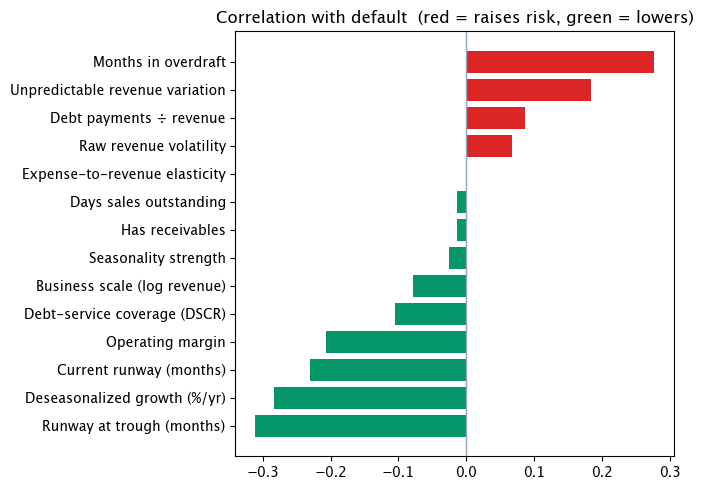

In [3]:
corr = df[FEATURE_NAMES].corrwith(df['default']).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#dc2626' if v > 0 else '#059669' for v in corr.values]
ax.barh([FEATURE_LABELS[f] for f in corr.index], corr.values, color=colors)
ax.axvline(0, color='#94a3b8', lw=1)
ax.set_title('Correlation with default  (red = raises risk, green = lowers)')
plt.tight_layout(); plt.show()

Thin **runway at the trough** and time spent **in overdraft** raise default risk; a healthy **operating margin** and **growth** lower it — exactly the signals the rule-based engine weights most.

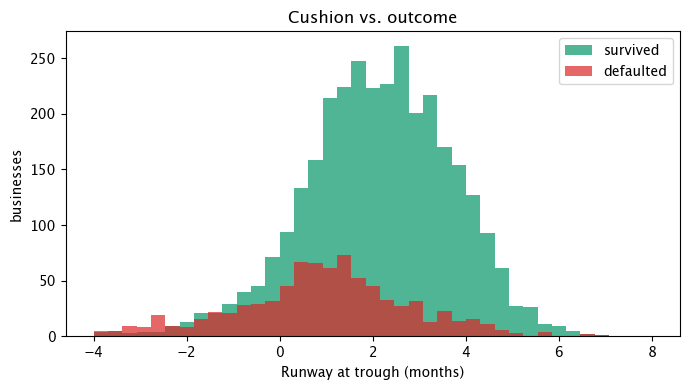

In [4]:
# Distribution of runway at trough, split by outcome.
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(-4, 8, 40)
ax.hist(df[df.default==0].runway_trough_mo, bins=bins, alpha=.7, label='survived', color='#059669')
ax.hist(df[df.default==1].runway_trough_mo, bins=bins, alpha=.7, label='defaulted', color='#dc2626')
ax.set(xlabel='Runway at trough (months)', ylabel='businesses', title='Cushion vs. outcome')
ax.legend(); plt.tight_layout(); plt.show()

## 3. Train & evaluate
Gradient boosting (headline) vs. a standardized logistic baseline, on a stratified held-out split.

In [5]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

X, y = df[FEATURE_NAMES], df['default']
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.25, random_state=42, stratify=y)

gbm = GradientBoostingClassifier(n_estimators=350, max_depth=3, learning_rate=.05, subsample=.9, random_state=42).fit(Xtr, ytr)
logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Xtr, ytr)
p = gbm.predict_proba(Xte)[:,1]

cv = cross_val_score(gbm, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring='roc_auc')
print(f'GBM   ROC-AUC (test) {roc_auc_score(yte,p):.3f}   CV {cv.mean():.3f} ± {cv.std():.3f}')
print(f'Logit ROC-AUC (test) {roc_auc_score(yte, logit.predict_proba(Xte)[:,1]):.3f}')
print(f'PR-AUC {average_precision_score(yte,p):.3f}  |  Brier {brier_score_loss(yte,p):.3f}  |  base rate {y.mean():.3f}')

GBM   ROC-AUC (test) 0.850   CV 0.830 ± 0.004
Logit ROC-AUC (test) 0.840
PR-AUC 0.654  |  Brier 0.112  |  base rate 0.209


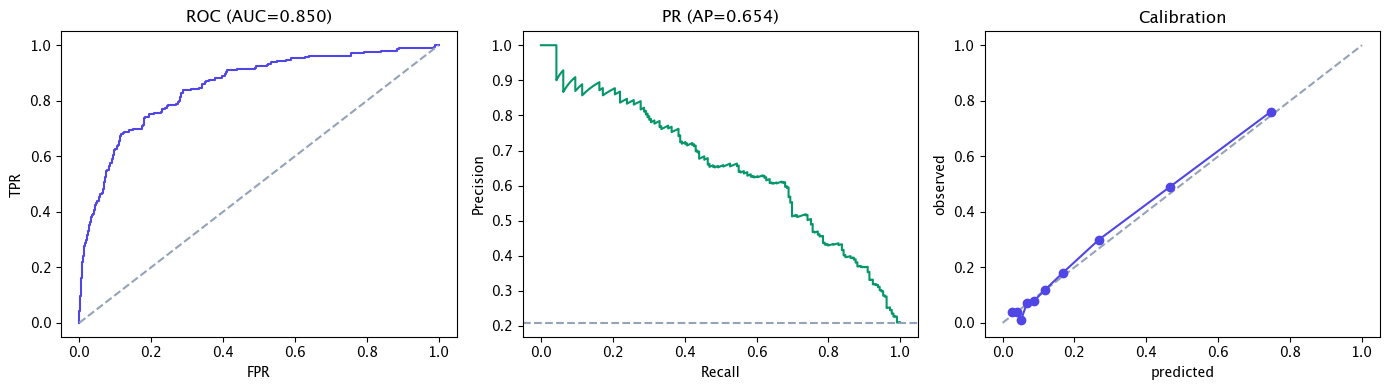

In [6]:
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.calibration import calibration_curve
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
fpr, tpr, _ = roc_curve(yte, p)
ax[0].plot(fpr, tpr, color='#4f46e5'); ax[0].plot([0,1],[0,1],'--',color='#94a3b8')
ax[0].set(title=f'ROC (AUC={roc_auc_score(yte,p):.3f})', xlabel='FPR', ylabel='TPR')
pr, rc, _ = precision_recall_curve(yte, p)
ax[1].plot(rc, pr, color='#059669'); ax[1].axhline(y.mean(), ls='--', color='#94a3b8')
ax[1].set(title=f'PR (AP={average_precision_score(yte,p):.3f})', xlabel='Recall', ylabel='Precision')
fp, mp = calibration_curve(yte, p, n_bins=10, strategy='quantile')
ax[2].plot([0,1],[0,1],'--',color='#94a3b8'); ax[2].plot(mp, fp, 'o-', color='#4f46e5')
ax[2].set(title='Calibration', xlabel='predicted', ylabel='observed')
plt.tight_layout(); plt.show()

## 4. Explainability (SHAP)
Which features drive the model globally — and does a learned model agree with the hand-built rules?

/Users/daejuangraham/Desktop/cashflow-underwriter/backend/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


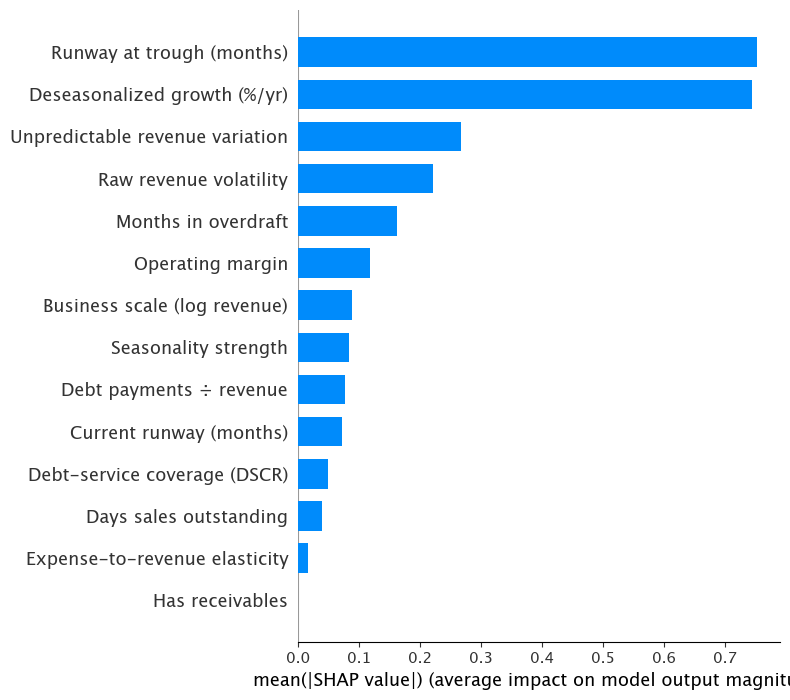

In [7]:
import shap
expl = shap.TreeExplainer(gbm)
sv = expl.shap_values(Xte)
shap.summary_plot(sv, Xte, feature_names=[FEATURE_LABELS[f] for f in FEATURE_NAMES], plot_type='bar', show=True)

## Takeaways
- **ROC-AUC ~0.85** on held-out data, with tight CV variance — the gradient-boosting model beats the linear baseline by capturing interaction effects (a decline is worse when the cushion is also thin).
- The model's most important features — **runway, growth trend, revenue predictability** — are the same signals Undercurrent's transparent rules weight most. The learned model *rediscovered the domain logic*.
- **Honest limitations:** labels are synthetic and the distribution is the generator's; metrics describe the pipeline, not real default. See `docs/MODEL_CARD.md`.